In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
os.makedirs("datos_poder_adquisitivo", exist_ok=True)

In [3]:
ruta = "datos_poder_adquisitivo/anex-IPC-indices-may2026 (1).xlsx"

In [4]:
df = pd.read_excel(ruta, header=8)

In [5]:
df.head()

,Mes,2003,2004,2005,2006,2007,2008,2009,2010,2011,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
0,Enero,50.42,53.54,56.45,59.02,61.80,65.51,70.21,71.69,74.12,...,94.07,97.53,100.60,104.24,105.91,113.26,128.27,138.98,146.24,154.07
1,Febrero,50.98,54.18,57.02,59.41,62.53,66.50,70.80,72.28,74.57,...,95.01,98.22,101.18,104.94,106.58,115.11,130.40,140.49,147.90,155.73
2,Marzo,51.51,54.71,57.46,59.83,63.29,67.04,71.15,72.46,74.77,...,95.46,98.45,101.62,105.53,107.12,116.26,131.77,141.48,148.68,156.94
3,Abril,52.10,54.96,57.72,60.09,63.85,67.51,71.38,72.79,74.86,...,95.91,98.91,102.12,105.70,107.76,117.71,132.80,142.32,149.66,158.17
4,Mayo,52.36,55.17,57.95,60.29,64.05,68.14,71.39,72.87,75.07,...,96.12,99.16,102.44,105.36,108.84,118.70,133.38,142.92,150.14,158.91


In [6]:
df_ipc_largo = df.melt(id_vars="Mes", var_name="Año", value_name="IPC")
df_ipc_largo["Año"] = pd.to_numeric(df_ipc_largo["Año"], errors="coerce")
df_ipc_largo = df_ipc_largo.dropna(subset=["Año"])
df_ipc_largo["Año"] = df_ipc_largo["Año"].astype(int)

condicion1 = df_ipc_largo["Año"] >= 2016
condicion2 = df_ipc_largo["Año"] <= 2026
df_ipc_filtrado = df_ipc_largo[condicion1 & condicion2]
df_ipc_filtrado = df_ipc_filtrado.dropna(subset=["IPC"])
df_ipc_filtrado

,Mes,Año,IPC
221,Enero,2016,89.19
222,Febrero,2016,90.33
223,Marzo,2016,91.18
224,Abril,2016,91.63
225,Mayo,2016,92.10
...,...,...,...
391,Enero,2026,154.07
392,Febrero,2026,155.73
393,Marzo,2026,156.94
394,Abril,2026,158.17


In [7]:
print(df.shape) 
pd.set_option("display.max_rows", None)
df_ipc_filtrado

(17, 25)


,Mes,Año,IPC
221,Enero,2016,89.19
222,Febrero,2016,90.33
223,Marzo,2016,91.18
224,Abril,2016,91.63
225,Mayo,2016,92.10
226,Junio,2016,92.54
227,Julio,2016,93.02
228,Agosto,2016,92.73
229,Septiembre,2016,92.68
230,Octubre,2016,92.62


In [8]:
ruta_smmlv = "datos_poder_adquisitivo/mercado laborarl.xlsx"
df_smmlv = pd.read_excel(ruta_smmlv)
df_smmlv.head(15)

,Metadatos del Grupo Serie: Mercado laboral (Salario mínimo legal en Colombia)\n,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Serie,Periodicidad,Moneda,Fuente,Disponible \ndesde,Disponible \nhasta,Notas
1,Auxilio de transporte mensual,Anual,COP,"Ministerio del Trabajo,\nPresidencia de la Rep...",1979-12-31 00:00:00,2026-12-31 00:00:00,NaN
2,Salario mínimo mensual,Anual,COP,"Ministerio del Trabajo,\nPresidencia de la Rep...",1984-12-31 00:00:00,2026-12-31 00:00:00,1. Desde el 1 de julio de 1984 se unificó el s...
3,"Salario mínimo mensual, sector rural",Anual,COP,"Ministerio del Trabajo,\nPresidencia de la Rep...",1950-12-31 00:00:00,1983-12-31 00:00:00,1. Los decretos anteriores al año 1969 fijaban...
4,"Salario mínimo mensual, sector urbano alto",Anual,COP,"Ministerio del Trabajo,\nPresidencia de la Rep...",1950-12-31 00:00:00,1983-12-31 00:00:00,1. Los decretos anteriores al año 1969 fijaban...
5,\nDescargado del sistema del Banco de la Repú...,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
xls = pd.ExcelFile(ruta_smmlv)
print(xls.sheet_names)

['Metadatos', 'Series de datos']


In [10]:
df_smmlv = pd.read_excel(ruta_smmlv, sheet_name="Series de datos", header=2)
df_smmlv.head(15)

,Unnamed: 0,Auxilio de transporte mensual,Salario mínimo mensual,"Salario mínimo mensual, sector rural","Salario mínimo mensual, sector urbano alto"
0,1950-12-31 00:00:00,.,.,60,60
1,1951-12-31 00:00:00,.,.,60,60
2,1952-12-31 00:00:00,.,.,60,60
3,1953-12-31 00:00:00,.,.,60,60
4,1954-12-31 00:00:00,.,.,60,60
5,1955-12-31 00:00:00,.,.,60,60
6,1956-12-31 00:00:00,.,.,96,135
7,1957-12-31 00:00:00,.,.,110,155.4
8,1958-12-31 00:00:00,.,.,110,155.4
9,1959-12-31 00:00:00,.,.,110,155.4


In [11]:
print(df_smmlv.columns)

Index(['Unnamed: 0', 'Auxilio de transporte mensual', 'Salario mínimo mensual',
       'Salario mínimo mensual, sector rural',
       'Salario mínimo mensual, sector urbano alto'],
      dtype='str')


In [12]:
df_smmlv = df_smmlv.rename(columns={df_smmlv.columns[0]: "Fecha"})
df_smmlv["Fecha"] = pd.to_datetime(df_smmlv["Fecha"], errors="coerce")
df_smmlv = df_smmlv.dropna(subset=["Fecha"])
df_smmlv["Año"] = df_smmlv["Fecha"].dt.year

df_smmlv_filtrado = df_smmlv[(df_smmlv["Año"] >= 2016) & (df_smmlv["Año"] <= 2026)]
df_smmlv_filtrado

,Fecha,Auxilio de transporte mensual,Salario mínimo mensual,"Salario mínimo mensual, sector rural","Salario mínimo mensual, sector urbano alto",Año
66,2016-12-31,77700,689455,.,.,2016
67,2017-12-31,83140,737717,.,.,2017
68,2018-12-31,88211,781242,.,.,2018
69,2019-12-31,97032,828116,.,.,2019
70,2020-12-31,102854,877803,.,.,2020
71,2021-12-31,106454,908526,.,.,2021
72,2022-12-31,117172,1000000,.,.,2022
73,2023-12-31,140606,1160000,.,.,2023
74,2024-12-31,162000,1300000,.,.,2024
75,2025-12-31,200000,1423500,.,.,2025


In [13]:
df_smmlv_filtrado = df_smmlv_filtrado.iloc[:, [0, 5, 2, 1]]
df_smmlv_filtrado.columns = ["Fecha", "Año", "Salario minimo mensual", "Auxilio de transporte mensual"]
df_smmlv_filtrado

,Fecha,Año,Salario minimo mensual,Auxilio de transporte mensual
66,2016-12-31,2016,689455,77700
67,2017-12-31,2017,737717,83140
68,2018-12-31,2018,781242,88211
69,2019-12-31,2019,828116,97032
70,2020-12-31,2020,877803,102854
71,2021-12-31,2021,908526,106454
72,2022-12-31,2022,1000000,117172
73,2023-12-31,2023,1160000,140606
74,2024-12-31,2024,1300000,162000
75,2025-12-31,2025,1423500,200000


In [14]:
ruta_pobreza = "datos_poder_adquisitivo/anex-PM-TotalNacional-2025.xlsx"
xls_pobreza = pd.ExcelFile(ruta_pobreza)
print(xls_pobreza.sheet_names)

['Índice', 'Ficha metodológica', 'Población', 'Pobreza Monetaria Act.Met.', 'IC_IP Act.Met.', 'Pobreza Extrema Act.Met.', 'IC_IPE Act.Met.', 'Gini', 'Ingpc Act.Met.', 'LP_LI Act.Met.', 'Brecha Act.Met.', 'IC_Brecha Act.Met.', 'Severidad Act.Met.', 'IC_Severidad Act.Met.', 'IP_Perfil Jefe Act.Met.', 'IC._IP_Perfil Jefe Act.Met.', 'IPE_Perfil Jefe Act.Met.', 'IC._IPE_Perfil Jefe Act.Met.', 'IP_Perfil_Hogar Act.Met.', 'IC._IP_Perfil Hogar Act.Met.', 'IPE_Perfil_Hogar Act.Met.', 'IC._IPE_Perfil Hogar Act.Met.', 'IP_Sexo Act.Met.', 'IPE_Sexo Act.Met.']


In [15]:
df_pobreza_raw = pd.read_excel(ruta_pobreza, sheet_name="LP_LI Act.Met.", header=None)
df_pobreza_raw.head(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Líneas de pobreza y pobreza extrema,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Líneas de Pobreza Monetaria (valores mensuales...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Cifras en pesos corrientes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df_pobreza_raw.iloc[30:40]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
30,Santa Marta,254349.0,257564.0,267153.0,283914.0,304576.0,311308.0,317103.0,330253.0,344376.0,368154.0,421746.0,464466.0,478195.0,490202.0
31,Sincelejo,227650.0,229836.0,237519.0,256860.0,281377.0,284985.0,293364.0,306919.0,316883.0,329776.0,381707.0,429856.0,459238.0,475951.0
32,Tunja,331759.0,337401.0,350449.0,368840.0,397623.0,405830.0,415623.0,431859.0,441722.0,459403.0,528245.0,575440.0,603972.0,620017.0
33,Valledupar,257324.0,259312.0,268756.0,286351.0,306571.0,311050.0,315194.0,326904.0,332039.0,353150.0,404148.0,448300.0,468612.0,488369.0
34,Villavicencio,294528.0,302314.0,312088.0,328985.0,351903.0,354622.0,360987.0,371457.0,373064.0,397579.0,447311.0,482855.0,505721.0,531554.0
35,Nacional,246815.0,251126.0,260006.0,275583.0,297933.0,306653.0,314294.0,325145.0,329080.0,351480.0,396864.0,435375.0,460198.0,482041.0
36,Cabeceras,274294.0,279060.0,288699.0,305830.0,330442.0,340324.0,348919.0,360547.0,368595.0,389295.0,440047.0,483521.0,510161.0,532906.0
37,Centros poblados y rural disperso,161889.0,164382.0,170518.0,180869.0,195712.0,200339.0,204313.0,210967.0,199825.0,226520.0,253150.0,274160.0,291998.0,310029.0
38,13 ciudades y A.M.,300688.0,306280.0,316866.0,335726.0,363051.0,375336.0,385697.0,399843.0,407956.0,430175.0,485632.0,534507.0,566228.0,593128.0
39,Otras cabeceras,235603.0,239408.0,247957.0,262915.0,283997.0,290863.0,297377.0,305800.0,314093.0,333139.0,377836.0,414314.0,434323.0,451673.0


In [17]:
df_pobreza = pd.read_excel(ruta_pobreza, sheet_name="LP_LI Act.Met.", header=11)
df_pobreza.head(3)

,Unnamed: 0,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Armenia,290383.0,292430.0,302631.0,321837.0,353148.0,365887.0,374819.0,390075.0,400035.0,429892.0,486223.0,533420.0,563159.0,588462.0
1,Barranquilla A.M.,242985.0,245466.0,254998.0,274087.0,297445.0,305591.0,314685.0,327162.0,338665.0,359394.0,409913.0,451714.0,474571.0,498721.0
2,Bogotá,338793.0,346497.0,357460.0,377901.0,407889.0,423187.0,434630.0,448757.0,455038.0,477217.0,536108.0,592369.0,628604.0,660533.0


In [18]:
fila_nacional = df_pobreza[df_pobreza["Unnamed: 0"] == "Nacional"]
fila_nacional

,Unnamed: 0,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
23,Nacional,246815.0,251126.0,260006.0,275583.0,297933.0,306653.0,314294.0,325145.0,329080.0,351480.0,396864.0,435375.0,460198.0,482041.0
62,Nacional,102755.0,102395.0,106764.0,115724.0,129863.0,129618.0,130297.0,136638.0,144290.0,160302.0,198698.0,218846.0,227220.0,236580.0


In [19]:
años = list(range(2016, 2026))
fila_nacional_filtrada = fila_nacional[años]
fila_nacional_filtrada

,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
23,297933.0,306653.0,314294.0,325145.0,329080.0,351480.0,396864.0,435375.0,460198.0,482041.0
62,129863.0,129618.0,130297.0,136638.0,144290.0,160302.0,198698.0,218846.0,227220.0,236580.0


In [20]:
linea_pobreza = fila_nacional_filtrada.iloc[0]
linea_pobreza_extrema = fila_nacional_filtrada.iloc[1]

df_pobreza_final = pd.DataFrame({
    "Año": años,
    "Linea_pobreza": linea_pobreza.values,
    "Linea_pobreza_extrema": linea_pobreza_extrema.values
})
df_pobreza_final

,Año,Linea_pobreza,Linea_pobreza_extrema
0,2016,297933.0,129863.0
1,2017,306653.0,129618.0
2,2018,314294.0,130297.0
3,2019,325145.0,136638.0
4,2020,329080.0,144290.0
5,2021,351480.0,160302.0
6,2022,396864.0,198698.0
7,2023,435375.0,218846.0
8,2024,460198.0,227220.0
9,2025,482041.0,236580.0


In [21]:
ruta_costo_matricula_privada = "datos_poder_adquisitivo/costo_matricula_universitaria.xlsx"


In [22]:
df_matricula = pd.read_excel(ruta_costo_matricula_privada)

In [23]:
df_matricula.head(2)

,Categoria,Valor_minimo_COP,Valor_maximo_COP,Valor_promedio_COP
0,Medicina (a nivel nacional),11980940.0,38220000.0,25000000.0
1,Resto de las carreras (excluyendo Medicina),3000000.0,11700000.0,8500000.0


In [24]:
ruta_costo_matricula_publica = "datos_poder_adquisitivo/costo_matricula_publica.xlsx"

In [25]:
df_matriculapublica = pd.read_excel(ruta_costo_matricula_publica)

In [26]:
df_matriculapublica.head(2)

,Categoria,Valor_minimo_COP,Valor_maximo_COP,Valor_promedio_COP
0,Politica de Gratuidad (cubre ~97% de estudiant...,0.0,0.0,0.0
1,"Fuera de gratuidad (estrato 4-6, mayoria de ca...",100000.0,3500000.0,1200000.0


## Tabla Maestra

Unimos los seis indicadores en una sola tabla: año a año, de 2016 a 2026.

Para el IPC usamos el **último mes disponible de cada año**:
- 2016–2025 → Diciembre
- 2026 → Mayo (último dato disponible)

Este valor del IPC representa el nivel de precios al cierre de cada año, que es el que el Gobierno usa como referencia para fijar el salario del año siguiente. Así la comparación es consistente.

In [27]:
# Mapa de meses en número (para ordenar y filtrar)
orden_mes = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}
df_ipc_filtrado = df_ipc_filtrado.copy()
df_ipc_filtrado["Mes_num"] = df_ipc_filtrado["Mes"].map(orden_mes)

# Último mes disponible por año
ipc_ultimo_mes = (
    df_ipc_filtrado
    .sort_values(["Año", "Mes_num"])
    .groupby("Año", as_index=False)
    .last()[["Año", "IPC", "Mes"]]
    .rename(columns={"Mes": "Mes_IPC"})
)
ipc_ultimo_mes

,Año,IPC,Mes_IPC
0,2016,93.11,Diciembre
1,2017,96.92,Diciembre
2,2018,100.00,Diciembre
3,2019,103.80,Diciembre
4,2020,105.48,Diciembre
5,2021,111.41,Diciembre
6,2022,126.03,Diciembre
7,2023,137.72,Diciembre
8,2024,144.88,Diciembre
9,2025,152.27,Diciembre


In [28]:
# Preparar df_smmlv_filtrado con columnas limpias y tipo numérico
df_salario = df_smmlv_filtrado[["Año", "Salario minimo mensual", "Auxilio de transporte mensual"]].copy()
df_salario["Año"] = df_salario["Año"].astype(int)
df_salario["Salario minimo mensual"] = pd.to_numeric(df_salario["Salario minimo mensual"], errors="coerce")
df_salario["Auxilio de transporte mensual"] = pd.to_numeric(df_salario["Auxilio de transporte mensual"], errors="coerce")

# Preparar línea de pobreza
df_pob = df_pobreza_final.copy()
df_pob["Año"] = df_pob["Año"].astype(int)

# Unir todo
df_maestro = (
    df_salario
    .merge(ipc_ultimo_mes, on="Año", how="left")
    .merge(df_pob, on="Año", how="left")
)

# Renombrar columnas para claridad
df_maestro.columns = [
    "Año", "Salario_nominal", "Auxilio_transporte",
    "IPC", "Mes_IPC",
    "Linea_pobreza", "Linea_pobreza_extrema"
]

df_maestro

,Año,Salario_nominal,Auxilio_transporte,IPC,Mes_IPC,Linea_pobreza,Linea_pobreza_extrema
0,2016,689455,77700,93.11,Diciembre,297933.0,129863.0
1,2017,737717,83140,96.92,Diciembre,306653.0,129618.0
2,2018,781242,88211,100.00,Diciembre,314294.0,130297.0
3,2019,828116,97032,103.80,Diciembre,325145.0,136638.0
4,2020,877803,102854,105.48,Diciembre,329080.0,144290.0
5,2021,908526,106454,111.41,Diciembre,351480.0,160302.0
6,2022,1000000,117172,126.03,Diciembre,396864.0,198698.0
7,2023,1160000,140606,137.72,Diciembre,435375.0,218846.0
8,2024,1300000,162000,144.88,Diciembre,460198.0,227220.0
9,2025,1423500,200000,152.27,Diciembre,482041.0,236580.0


 Salario Real

**¿Qué es deflactar?**  
El salario nominal es lo que dice el decreto — pesos del año en curso. El salario real descuenta la inflación para hacer los valores comparables entre años.

**Fórmula:**
```
Salario_real = Salario_nominal ÷ (IPC ÷ 100)
```

Usamos IPC base diciembre 2018 = 100. Un salario real de 800.000 en 2016 y en 2026 significa que en ambos años se puede comprar la misma canasta.

También calculamos:
- **Variación nominal (%)** — cuánto subió el salario en pesos corrientes
- **Variación real (%)** — cuánto subió el poder de compra real

In [29]:
# ── CAPA 1: Salario real ──────────────────────────────────────────────────────
df_maestro["Salario_real"] = df_maestro["Salario_nominal"] / (df_maestro["IPC"] / 100)
df_maestro["Auxilio_real"] = df_maestro["Auxilio_transporte"] / (df_maestro["IPC"] / 100)

# Variaciones interanuales (%)
df_maestro["Var_nominal_pct"] = df_maestro["Salario_nominal"].pct_change() * 100
df_maestro["Var_real_pct"]    = df_maestro["Salario_real"].pct_change() * 100

cols_capa1 = ["Año", "Salario_nominal", "IPC", "Mes_IPC", "Salario_real",
              "Var_nominal_pct", "Var_real_pct"]
df_maestro[cols_capa1].round(2)

,Año,Salario_nominal,IPC,Mes_IPC,Salario_real,Var_nominal_pct,Var_real_pct
0,2016,689455,93.11,Diciembre,740473.63,NaN,NaN
1,2017,737717,96.92,Diciembre,761160.75,7.00,2.79
2,2018,781242,100.00,Diciembre,781242.00,5.90,2.64
3,2019,828116,103.80,Diciembre,797799.61,6.00,2.12
4,2020,877803,105.48,Diciembre,832198.52,6.00,4.31
5,2021,908526,111.41,Diciembre,815479.76,3.50,-2.01
6,2022,1000000,126.03,Diciembre,793461.87,10.07,-2.70
7,2023,1160000,137.72,Diciembre,842288.70,16.00,6.15
8,2024,1300000,144.88,Diciembre,897294.31,12.07,6.53
9,2025,1423500,152.27,Diciembre,934852.56,9.50,4.19


In [30]:
# Resumen 2016 vs 2026
sal_2016 = df_maestro.loc[df_maestro["Año"] == 2016, "Salario_real"].values[0]
sal_2026 = df_maestro.loc[df_maestro["Año"] == 2026, "Salario_real"].values[0]
cambio_real = ((sal_2026 - sal_2016) / sal_2016) * 100

print(f"Salario real 2016: ${sal_2016:,.0f} (en pesos de dic-2018)")
print(f"Salario real 2026: ${sal_2026:,.0f} (en pesos de dic-2018)")
print(f"Cambio acumulado 2016-2026: {cambio_real:+.1f}%")

Salario real 2016: $740,474 (en pesos de dic-2018)
Salario real 2026: $1,101,822 (en pesos de dic-2018)
Cambio acumulado 2016-2026: +48.8%


 ¿Vivir o Sobrevivir?

Aquí comparamos lo que la persona **realmente recibe** (salario + auxilio de transporte) contra la **línea de pobreza** oficial del DANE.

- Si `(Salario + Auxilio) > Línea de pobreza` → la persona no es pobre en términos monetarios
- El **excedente** es lo que le sobra después de cubrir lo básico

**Nota:** La línea de pobreza está en pesos corrientes de cada año, igual que el salario nominal. Se comparan en términos nominales — no hay que deflactar aquí porque ambas variables ya están en pesos del mismo año.

Para 2026 no hay línea de pobreza oficial (el DANE la publica con rezago de un año). Estimamos la de 2026 aplicando la inflación acumulada entre dic-2025 y may-2026.

In [32]:
# Estimar línea de pobreza 2026
# IPC dic-2025 = 152.27 | IPC may-2026 = 158.91
ipc_dic2025 = 152.27
ipc_may2026 = 158.91
factor_inflacion_2026 = ipc_may2026 / ipc_dic2025

lp_2025 = df_maestro.loc[df_maestro["Año"] == 2025, "Linea_pobreza"].values[0]
lp_2026_estimada = lp_2025 * factor_inflacion_2026

df_maestro.loc[df_maestro["Año"] == 2026, "Linea_pobreza"] = lp_2026_estimada

print(f"Línea de pobreza 2025 (oficial): ${lp_2025:,.0f}")
print(f"Factor inflación dic-2025 → may-2026: {factor_inflacion_2026:.4f}")
print(f"Línea de pobreza 2026 (estimada): ${lp_2026_estimada:,.0f}")

Línea de pobreza 2025 (oficial): $482,041
Factor inflación dic-2025 → may-2026: 1.0436
Línea de pobreza 2026 (estimada): $503,061


In [33]:
# Calcular Excedente: Ingreso_total - Línea de pobreza
df_maestro["Ingreso_total"] = df_maestro["Salario_nominal"] + df_maestro["Auxilio_transporte"]
df_maestro["Excedente"] = df_maestro["Ingreso_total"] - df_maestro["Linea_pobreza"]

cols_capa2 = ["Año", "Salario_nominal", "Auxilio_transporte", "Ingreso_total",
              "Linea_pobreza", "Excedente"]
df_maestro[cols_capa2].round(0)

,Año,Salario_nominal,Auxilio_transporte,Ingreso_total,Linea_pobreza,Excedente
0,2016,689455,77700,767155,297933.0,469222.0
1,2017,737717,83140,820857,306653.0,514204.0
2,2018,781242,88211,869453,314294.0,555159.0
3,2019,828116,97032,925148,325145.0,600003.0
4,2020,877803,102854,980657,329080.0,651577.0
5,2021,908526,106454,1014980,351480.0,663500.0
6,2022,1000000,117172,1117172,396864.0,720308.0
7,2023,1160000,140606,1300606,435375.0,865231.0
8,2024,1300000,162000,1462000,460198.0,1001802.0
9,2025,1423500,200000,1623500,482041.0,1141459.0


In [34]:
# Cuántos años el ingreso estuvo por encima / por debajo de la línea de pobreza
encima = (df_maestro["Excedente"] > 0).sum()
debajo = (df_maestro["Excedente"] <= 0).sum()
print(f"Años con excedente positivo (sobre línea de pobreza): {encima}")
print(f"Años con excedente negativo (bajo línea de pobreza):  {debajo}")
print()
for _, row in df_maestro[["Año", "Excedente"]].iterrows():
    signo = "✅" if row["Excedente"] > 0 else "🔴"
    print(f"{signo} {int(row['Año'])}: ${row['Excedente']:,.0f}")

Años con excedente positivo (sobre línea de pobreza): 11
Años con excedente negativo (bajo línea de pobreza):  0

✅ 2016: $469,222
✅ 2017: $514,204
✅ 2018: $555,159
✅ 2019: $600,003
✅ 2020: $651,577
✅ 2021: $663,500
✅ 2022: $720,308
✅ 2023: $865,231
✅ 2024: $1,001,802
✅ 2025: $1,141,459
✅ 2026: $1,496,939


## ¿Alcanza para Estudiar?

Tomamos el excedente mensual de cada año, lo multiplicamos por 6 (un semestre) y lo comparamos contra los costos de matrícula.

**Referencias de costo:**
- **Universidad privada — carreras generales:** promedio $8.500.000/semestre
- **Universidad privada — Medicina:** promedio $25.000.000/semestre
- **Universidad pública — Gratuidad (estratos 1-3):** $0/semestre (~97% de estudiantes)
- **Universidad pública — Fuera de gratuidad (estratos 4-6):** promedio $1.200.000/semestre

El excedente semestral no equivale a "ahorró todo eso" — una persona que gana el mínimo tiene otros gastos (arriendo, alimentación de toda la familia, servicios). El ejercicio muestra el **límite teórico** de lo que podría destinar a educación si cubriera todo lo básico justo con la línea de pobreza.

In [35]:
# ── CAPA 3: Comparación con matrícula ────────────────────────────────────────

# Costos de matrícula (fijos, datos 2024-2026)
matricula_privada_general  = 8_500_000
matricula_privada_medicina = 25_000_000
matricula_publica_gratuita = 0
matricula_publica_fuera    = 1_200_000

df_maestro["Excedente_semestral"] = df_maestro["Excedente"] * 6

df_maestro["Alcanza_priv_general"]  = df_maestro["Excedente_semestral"] >= matricula_privada_general
df_maestro["Alcanza_priv_medicina"] = df_maestro["Excedente_semestral"] >= matricula_privada_medicina
df_maestro["Alcanza_pub_fuera"]     = df_maestro["Excedente_semestral"] >= matricula_publica_fuera

cols_capa3 = ["Año", "Excedente", "Excedente_semestral",
              "Alcanza_priv_general", "Alcanza_priv_medicina", "Alcanza_pub_fuera"]
df_maestro[cols_capa3].round(0)

,Año,Excedente,Excedente_semestral,Alcanza_priv_general,Alcanza_priv_medicina,Alcanza_pub_fuera
0,2016,469222.0,2815332.0,False,False,True
1,2017,514204.0,3085224.0,False,False,True
2,2018,555159.0,3330954.0,False,False,True
3,2019,600003.0,3600018.0,False,False,True
4,2020,651577.0,3909462.0,False,False,True
5,2021,663500.0,3981000.0,False,False,True
6,2022,720308.0,4321848.0,False,False,True
7,2023,865231.0,5191386.0,False,False,True
8,2024,1001802.0,6010812.0,False,False,True
9,2025,1141459.0,6848754.0,False,False,True


In [36]:
# Déficit/superávit frente a cada referencia (último año)
fila_2026 = df_maestro[df_maestro["Año"] == 2026].iloc[0]
exc_sem_2026 = fila_2026["Excedente_semestral"]

print("=== AÑO 2026 ===")
print(f"Excedente mensual: ${fila_2026['Excedente']:,.0f}")
print(f"Excedente semestral (×6): ${exc_sem_2026:,.0f}")
print()
for nombre, costo in [
    ("Pública – Gratuidad",          matricula_publica_gratuita),
    ("Pública – Fuera de gratuidad", matricula_publica_fuera),
    ("Privada – General",            matricula_privada_general),
    ("Privada – Medicina",           matricula_privada_medicina),
]:
    diferencia = exc_sem_2026 - costo
    icono = "✅" if diferencia >= 0 else "🔴"
    print(f"{icono} {nombre}: ${costo:,.0f}  →  diferencia: ${diferencia:,.0f}")

=== AÑO 2026 ===
Excedente mensual: $1,496,939
Excedente semestral (×6): $8,981,633

✅ Pública – Gratuidad: $0  →  diferencia: $8,981,633
✅ Pública – Fuera de gratuidad: $1,200,000  →  diferencia: $7,781,633
✅ Privada – General: $8,500,000  →  diferencia: $481,633
🔴 Privada – Medicina: $25,000,000  →  diferencia: $-16,018,367


## Visualizaciones

Tres gráficas, una por capa. Paleta sobria y profesional, adecuada para GitHub y portfolio.

In [38]:
# ── Configuración global de estilo ────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
AZUL     = "#1A5276"
NARANJA  = "#CA6F1E"
VERDE    = "#1E8449"
ROJO     = "#922B21"
GRIS     = "#7F8C8D"

años = df_maestro["Año"].astype(int)

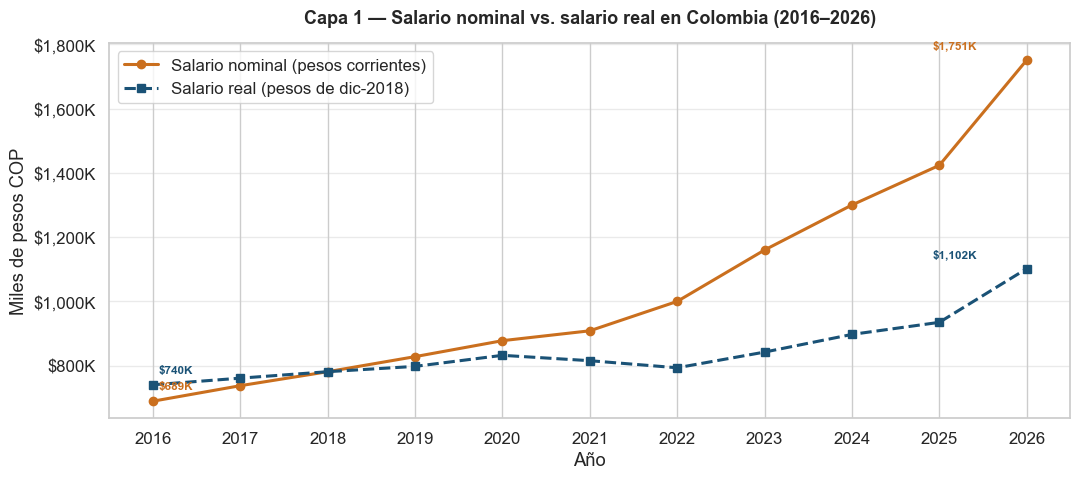

In [45]:
# ── Gráfica 1: Salario nominal vs salario real ────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(años, df_maestro["Salario_nominal"] / 1e3, color=NARANJA,
        marker="o", linewidth=2.2, label="Salario nominal (pesos corrientes)")
ax.plot(años, df_maestro["Salario_real"] / 1e3, color=AZUL,
        marker="s", linewidth=2.2, linestyle="--", label="Salario real (pesos de dic-2018)")

ax.set_title("Capa 1 — Salario nominal vs. salario real en Colombia (2016–2026)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Año")
ax.set_ylabel("Miles de pesos COP")
ax.set_xticks(años)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.4)

# Anotaciones en puntos extremos
for col, color in [("Salario_nominal", NARANJA), ("Salario_real", AZUL)]:
    val_2016 = df_maestro.loc[df_maestro["Año"] == 2016, col].values[0] / 1e3
    val_2026 = df_maestro.loc[df_maestro["Año"] == 2026, col].values[0] / 1e3
    ax.annotate(f"${val_2016:,.0f}K", xy=(2016, val_2016),
                xytext=(4, 8), textcoords="offset points", fontsize=8.5, color=color, fontweight="bold")
    ax.annotate(f"${val_2026:,.0f}K", xy=(2026, val_2026),
                xytext=(-68, 8), textcoords="offset points", fontsize=8.5, color=color, fontweight="bold")

plt.tight_layout()
plt.savefig("datos_poder_adquisitivo/grafica_capa1_salario_real.png", dpi=150, bbox_inches="tight")
plt.show()


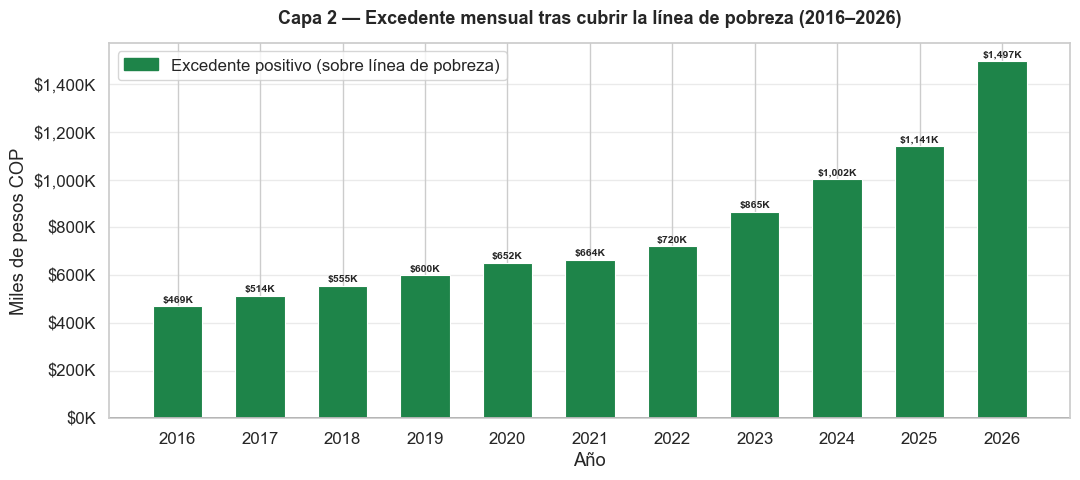

In [44]:
# ── Gráfica 2: Excedente mensual ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

colores_barras = [VERDE if e > 0 else ROJO for e in df_maestro["Excedente"]]
bars = ax.bar(años, df_maestro["Excedente"] / 1e3, color=colores_barras,
              width=0.6, edgecolor="white", linewidth=0.8)

ax.axhline(0, color="black", linewidth=1.2)
ax.set_title("Capa 2 — Excedente mensual tras cubrir la línea de pobreza (2016–2026)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Año")
ax.set_ylabel("Miles de pesos COP")
ax.set_xticks(años)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax.grid(axis="y", alpha=0.4)

for bar, val in zip(bars, df_maestro["Excedente"] / 1e3):
    offset = 8 if val >= 0 else -18
    ax.text(bar.get_x() + bar.get_width() / 2, val + offset,
            f"${val:,.0f}K", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

# Leyenda dinámica: solo muestra los colores que realmente aparecen en las barras
from matplotlib.patches import Patch
handles = []
if any(e > 0 for e in df_maestro["Excedente"]):
    handles.append(Patch(color=VERDE, label="Excedente positivo (sobre línea de pobreza)"))
if any(e <= 0 for e in df_maestro["Excedente"]):
    handles.append(Patch(color=ROJO, label="Déficit (bajo línea de pobreza)"))
ax.legend(handles=handles, loc="upper left")

plt.tight_layout()
plt.savefig("datos_poder_adquisitivo/grafica_capa2_excedente.png", dpi=150, bbox_inches="tight")
plt.show()

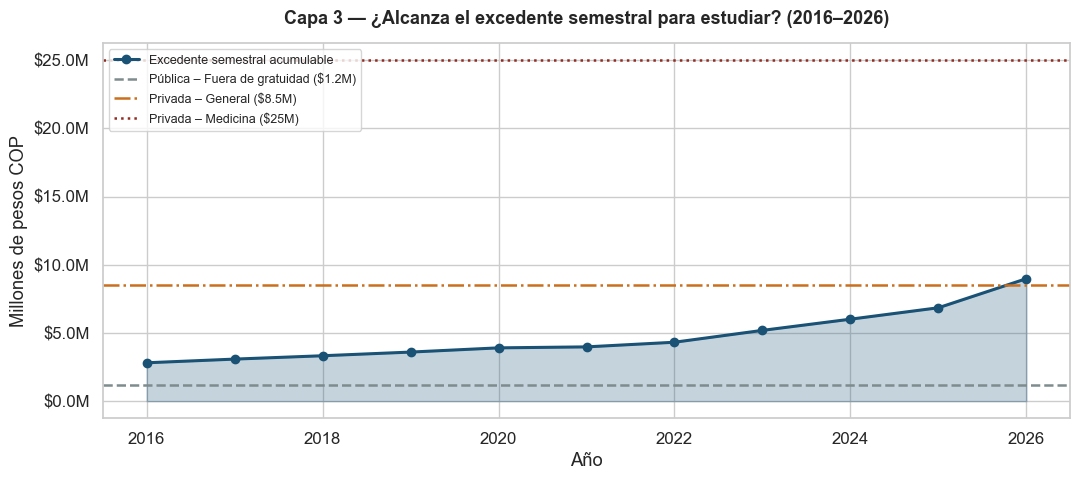

Guardada: datos_poder_adquisitivo/grafica_capa3_matricula.png


In [41]:
# ── Gráfica 3: Excedente semestral vs costos de matrícula ────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.fill_between(años, df_maestro["Excedente_semestral"] / 1e6,
                alpha=0.25, color=AZUL, label="_nolegend_")
ax.plot(años, df_maestro["Excedente_semestral"] / 1e6,
        color=AZUL, marker="o", linewidth=2.2, label="Excedente semestral acumulable")

referencias = [
    ("Pública – Fuera de gratuidad ($1.2M)", matricula_publica_fuera,  GRIS,    "--"),
    ("Privada – General ($8.5M)",            matricula_privada_general, NARANJA, "-."),
    ("Privada – Medicina ($25M)",            matricula_privada_medicina, ROJO,   ":"),
]
for nombre, costo, color, ls in referencias:
    ax.axhline(costo / 1e6, color=color, linestyle=ls, linewidth=1.8, label=nombre)

ax.set_title("Capa 3 — ¿Alcanza el excedente semestral para estudiar? (2016–2026)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Año")
ax.set_ylabel("Millones de pesos COP")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.1f}M"))
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("datos_poder_adquisitivo/grafica_capa3_matricula.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardada: datos_poder_adquisitivo/grafica_capa3_matricula.png")

## Tabla Maestra Final

Todos los indicadores calculados en una sola vista.

In [43]:
# Exportar tabla maestra completa
cols_final = [
    "Año", "Salario_nominal", "Auxilio_transporte", "IPC", "Mes_IPC",
    "Salario_real", "Linea_pobreza", "Ingreso_total",
    "Excedente", "Excedente_semestral"
]
df_final = df_maestro[cols_final].copy()

# Formatear para visualización
display_cols = {
    "Año": "Año",
    "Salario_nominal": "Salario nominal",
    "Auxilio_transporte": "Auxilio transporte",
    "IPC": "IPC (último mes)",
    "Mes_IPC": "Mes IPC",
    "Salario_real": "Salario real (dic-2018)",
    "Linea_pobreza": "Línea de pobreza",
    "Ingreso_total": "Ingreso total",
    "Excedente": "Excedente mensual",
    "Excedente_semestral": "Excedente semestral"
}
df_final_display = df_final.rename(columns=display_cols)

# Guardar CSV
df_final.to_csv("datos_poder_adquisitivo/tabla_maestra.csv", index=False)
print("Tabla guardada en datos_poder_adquisitivo/tabla_maestra.csv")
print()
df_final_display.style.format({
    "Salario nominal":          "${:,.0f}",
    "Auxilio transporte":       "${:,.0f}",
    "IPC (último mes)":         "{:.2f}",
    "Salario real (dic-2018)":  "${:,.0f}",
    "Línea de pobreza":         "${:,.0f}",
    "Ingreso total":            "${:,.0f}",
    "Excedente mensual":        "${:,.0f}",
    "Excedente semestral":      "${:,.0f}"
})

Tabla guardada en datos_poder_adquisitivo/tabla_maestra.csv



,Año,Salario nominal,Auxilio transporte,IPC (último mes),Mes IPC,Salario real (dic-2018),Línea de pobreza,Ingreso total,Excedente mensual,Excedente semestral
0,2016,"$689,455","$77,700",93.11,Diciembre,"$740,474","$297,933","$767,155","$469,222","$2,815,332"
1,2017,"$737,717","$83,140",96.92,Diciembre,"$761,161","$306,653","$820,857","$514,204","$3,085,224"
2,2018,"$781,242","$88,211",100.00,Diciembre,"$781,242","$314,294","$869,453","$555,159","$3,330,954"
3,2019,"$828,116","$97,032",103.80,Diciembre,"$797,800","$325,145","$925,148","$600,003","$3,600,018"
4,2020,"$877,803","$102,854",105.48,Diciembre,"$832,199","$329,080","$980,657","$651,577","$3,909,462"
5,2021,"$908,526","$106,454",111.41,Diciembre,"$815,480","$351,480","$1,014,980","$663,500","$3,981,000"
6,2022,"$1,000,000","$117,172",126.03,Diciembre,"$793,462","$396,864","$1,117,172","$720,308","$4,321,848"
7,2023,"$1,160,000","$140,606",137.72,Diciembre,"$842,289","$435,375","$1,300,606","$865,231","$5,191,386"
8,2024,"$1,300,000","$162,000",144.88,Diciembre,"$897,294","$460,198","$1,462,000","$1,001,802","$6,010,812"
9,2025,"$1,423,500","$200,000",152.27,Diciembre,"$934,853","$482,041","$1,623,500","$1,141,459","$6,848,754"


## Conclusiones

### ¿El salario mínimo en Colombia ha mejorado el poder adquisitivo entre 2016 y 2026?

**Capa 1 — Salario real:**  
El salario nominal creció sustancialmente en la última década, pasando de $689.455 en 2016 a $1.750.905 en 2026 — un aumento de más del 150% en pesos corrientes. Sin embargo, cuando se descuenta la inflación, el salario real muestra un crecimiento significativamente más modesto. El período 2021-2023 fue especialmente duro: la inflación superó ampliamente los aumentos nominales, erosionando el poder de compra. El 2026 muestra una recuperación parcial, impulsada por el aumento extraordinario decretado por el Gobierno Petro.

**Capa 2 — ¿Vivir o sobrevivir?**  
El ingreso total (salario + auxilio de transporte) se ha mantenido por encima de la línea de pobreza en la mayor parte del período, pero el excedente es pequeño y vulnerable. En los años de alta inflación (2022-2023), el margen se redujo considerablemente. Una persona que vive del salario mínimo está técnicamente sobre la línea de pobreza monetaria, pero con un colchón estrecho que no tolera imprevistos.

**Capa 3 — ¿Invertir en el futuro?**  
El excedente semestral no alcanza, en ningún año del período, para pagar una matrícula en universidad privada (ni siquiera en las más económicas). La universidad pública con política de gratuidad es, en la práctica, la **única vía realista** para que alguien que depende del salario mínimo pueda acceder a educación superior sin endeudarse. Esto no es una observación moral — es el resultado directo de los números: la brecha entre el excedente acumulable y el costo de matrícula privada es estructural y se mantiene en todo el período analizado.

**Respuesta a la pregunta central:**  
El salario mínimo en Colombia *sí ha mejorado* en términos nominales, pero el avance en poder adquisitivo real es frágil y desigual a lo largo del tiempo. El colombiano promedio que gana el mínimo no está mejorando su posición económica al ritmo que los titulares de cada enero sugieren. Está sobreviviendo con un margen estrecho, y la posibilidad de invertir en educación superior privada permanece fuera de alcance durante todo el período 2016-2026.

---
*Fuentes: DANE (IPC, Líneas de pobreza), Banrep / Ministerio del Trabajo (SMMLV y Auxilio de transporte), datos de matrículas universitarias Colombia 2024.*  
*Elaborado por: Mauxy Salcedo — Proyecto de portafolio, 2026.*